In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean.json


In [3]:
df = pd.read_json('dataset_Analyse_des_sentiments_clean.json')

df.head()

,Date,Auteur,Note,Version,Titre,Commentaire,Votes,satisfaction,YearMonth,word_count,clean_commentaire,clean_Titre
0,2025-09-23 13:06:00,Svent's,3,2.1.0,Bonne app mais…,"Belle interface sur iPhone, il manque juste la...",0,neutral,2025-09,34,belle interface sur iphone manque juste foncti...,bonne app mais
1,2025-09-24 06:53:00,mikael357,2,2.1.0,Pas assez intuitive,Je trouve que la nouvelle appli n’est vraiment...,0,negative,2025-09,57,trouve que nouvelle appli est vraiment pas int...,pas assez intuitive
2,2025-09-26 12:47:00,tomusspupuce,5,2.1.0,Très bon produit,Instantanément. Intelligent. Connecté.,0,positive,2025-09,3,instantanement intelligent connecte,tres bon produit
3,2025-09-27 11:24:00,Joueur Curling,5,2.1.0,Parfait,"Très utile, plus besoin de penser à ce qu’il f...",0,positive,2025-09,19,tres utile plus besoin penser faut faire surto...,parfait
4,2025-09-28 00:39:00,Amonyme,3,2.1.0,Arrêtez la mise à jour intempestive svp,L’app est simple et pratique mais il y a une s...,0,neutral,2025-09,42,app est simple pratique mais une sorte big qui...,arretez mise jour intempestive svp


In [4]:
df['satisfaction'].value_counts()

,count
satisfaction,
positive,211
negative,185
neutral,104


# **TF-IDF**

In [5]:
df["full_text"] = (
    df["clean_Titre"].astype(str)
    + " "
    + df["clean_commentaire"].astype(str)
)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df["full_text"]
)

y = df["satisfaction"]

# **Train / Test Split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Logistic Regression(baseline)**

In [7]:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.61      0.68      0.64        37
     neutral       1.00      0.05      0.09        21
    positive       0.59      0.81      0.68        42

    accuracy                           0.60       100
   macro avg       0.73      0.51      0.47       100
weighted avg       0.68      0.60      0.54       100



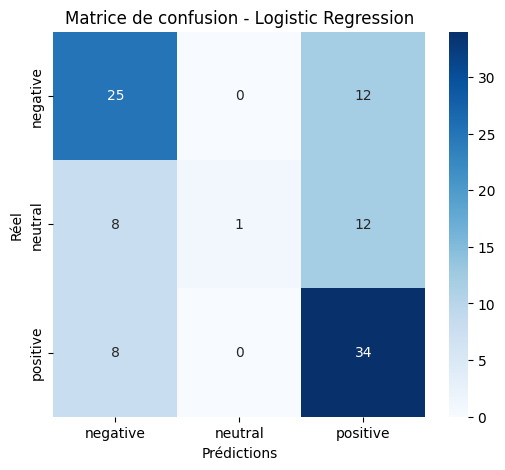

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.title('Matrice de confusion - Logistic Regression')

plt.show()

# **Logistic Regression + Class Weight**

In [10]:
lr_weighted = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr_weighted.fit(X_train, y_train)

y_pred_weighted = lr_weighted.predict(X_test)

print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

    negative       0.57      0.62      0.60        37
     neutral       0.35      0.29      0.32        21
    positive       0.60      0.62      0.61        42

    accuracy                           0.55       100
   macro avg       0.51      0.51      0.51       100
weighted avg       0.54      0.55      0.54       100



# **Logistic Regression + SMOTE**

In [11]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [12]:
lr_smote = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

    negative       0.57      0.65      0.61        37
     neutral       0.33      0.19      0.24        21
    positive       0.59      0.64      0.61        42

    accuracy                           0.55       100
   macro avg       0.50      0.49      0.49       100
weighted avg       0.53      0.55      0.53       100



# **Comparaison**

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Logistic + Class Weight',
        'Logistic + SMOTE'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_smote)
    ],

    'Precision': [
        precision_score(y_test, y_pred, average='weighted'),
        precision_score(y_test, y_pred_weighted, average='weighted'),
        precision_score(y_test, y_pred_smote, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred_weighted, average='weighted'),
        recall_score(y_test, y_pred_smote, average='weighted')
    ],

    'F1-score': [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred_weighted, average='weighted'),
        f1_score(y_test, y_pred_smote, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.60,0.681817,0.60,0.541870
1,Logistic + Class Weight,0.55,0.540821,0.55,0.544296
2,Logistic + SMOTE,0.55,0.527950,0.55,0.533446
